Assignment 8

Name: Shantanu Kaute | Roll No. 07 | PRN no. 1252090007

Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing      

            details of customers to predict customer response for special offer. Create confusion  

            matrix based on above data and find
            Accuracy
            Precision
            Recall
            F-1 score

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Read Cosmetics Dataset

In [ ]:
df = pd.read_csv("cards.csv")

print("Original Shape:", df.shape)
print(df.head())
print(df.columns)

Original Shape: (8155, 5)
   class index                   filepaths        labels card type data set
0            0  train/ace of clubs/001.jpg  ace of clubs       ace    train
1            0  train/ace of clubs/002.jpg  ace of clubs       ace    train
2            0  train/ace of clubs/003.jpg  ace of clubs       ace    train
3            0  train/ace of clubs/004.jpg  ace of clubs       ace    train
4            0  train/ace of clubs/005.jpg  ace of clubs       ace    train
Index(['class index', 'filepaths', 'labels', 'card type', 'data set'], dtype='object')


Data Cleaning

In [ ]:

df = df.drop_duplicates()

df = df.dropna()

print("After Cleaning Shape:", df.shape)

After Cleaning Shape: (8155, 5)


Encode Target Variable

In [ ]:
df['class index'] = df['class index'].astype('category').cat.codes

print("Target Classes:", df['class index'].unique())

Target Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52]


Separate Features & Target

In [ ]:
print(df.columns)

Index(['class index', 'filepaths', 'labels', 'card type', 'data set'], dtype='object')


In [ ]:
df['class index'] = df['class index'].astype('category').cat.codes

In [ ]:
X = df.drop("class index", axis=1)
y = df["class index"]

print("Unique classes:", y.unique())

Unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52]


Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Logistic Regression Model

In [ ]:
import pandas as pd

X_train_processed = X_train.drop(columns=['filepaths', 'data set']).copy()
X_test_processed = X_test.drop(columns=['filepaths', 'data set']).copy()

categorical_cols = ['labels', 'card type']
X_train_processed = pd.get_dummies(X_train_processed, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test_processed, columns=categorical_cols, drop_first=True)

train_cols = X_train_processed.columns

X_test_processed = X_test_processed.reindex(columns=train_cols, fill_value=0)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[31  0  0 ...  0  0  0]
 [ 0 26  0 ...  0  0  0]
 [ 0  0 29 ...  0  0  0]
 ...
 [ 0  0  0 ... 23  0  0]
 [ 0  0  0 ...  0 25  0]
 [ 0  0  0 ...  0  0 30]]


Evaluation Metrics

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Plot Confusion Matrix

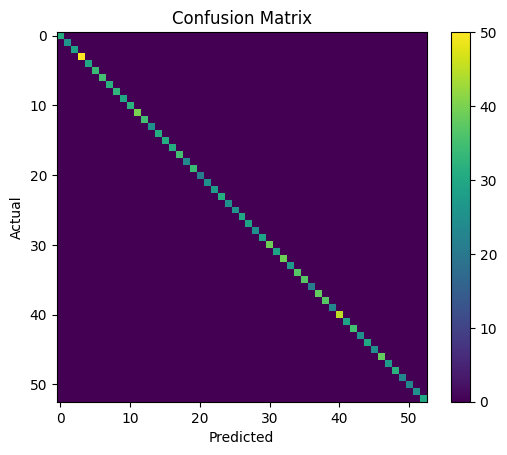

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()